# Random Forest & Decision Tree - Gokulkrishna Santoshkumar
COMM074 · Airline Route Profitability Prediction

**Student:** Gokulkrishna Santoshkumar  
**Primary model:** Random Forest (ensemble)  
**Comparison:** Decision Tree (independently tuned)  
**Key question:** How much does the ensemble gain over a single well-tuned tree, and at what cost to interpretability?

---

| Metric | Why it matters here |
|--------|---------------------|
| F1-Score | Balances FP and FN. Primary target throughout. |
| ROC-AUC | Ranking quality at all thresholds - used cross-model. |
| MCC | Uses all four confusion matrix cells; harder to game than accuracy. |
| TNR | Rate of correctly identified loss-making routes. |
| FPR | False alarm rate - approving routes that will lose money. |
| Overfit Gap | Train F1 − Test F1. < 0.05 fine; > 0.10 signals memorisation. |

## 1. Setup

Standard stack: numpy, pandas, sklearn. All five group notebooks share the same imports.

In [1]:
import os, json, pickle, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_score, learning_curve)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report,
                              matthews_corrcoef)

print('Libraries loaded.')

Libraries loaded.


## 2. Paths and data

> Tree splits compare feature values against thresholds - the absolute scale of each feature has no effect on which side of a threshold a sample falls. Raw unscaled features work directly for both RF and DT.

In [7]:
from pathlib import Path

# ── Project-level constants ───────────────────────────────────────────────────
RANDOM_STATE = 42
STUDENT      = 'gokulkrishna'
FP_COST      = 42000   # £/route: approving a loss-making route for one quarter
FN_COST      = 30000   # £/route: retiring a profitable route incorrectly

# ── Directory layout ──────────────────────────────────────────────────────────
NB_DIR    = Path.cwd()
PROJ_ROOT = NB_DIR.parent
PROC_DIR  = PROJ_ROOT / "processed_data"
FIG_DIR   = NB_DIR / "figures"
NB_DIR.mkdir(parents=True, exist_ok=True)

# ── Colour palette ────────────────────────────────────────────────────────────
C_PROFIT  = '#2DC653'
C_LOSS    = '#E84855'
C_NEUTRAL = '#2E86AB'

# ── Load splits (unscaled; tree models don't need standardisation) ────────────
X_train = pd.read_csv(PROC_DIR / "X_train.csv")
X_val   = pd.read_csv(PROC_DIR / "X_val.csv")
X_test  = pd.read_csv(PROC_DIR / "X_test.csv")

y_train = pd.read_csv(PROC_DIR / "y_train.csv").squeeze()
y_val   = pd.read_csv(PROC_DIR / "y_val.csv").squeeze()
y_test  = pd.read_csv(PROC_DIR / "y_test.csv").squeeze()

with open(PROC_DIR / "feature_names.json") as f:
    feature_names = json.load(f)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Class balance - Train: {y_train.mean():.3f}, Val: {y_val.mean():.3f}, Test: {y_test.mean():.3f}')

Train: (11997, 40), Val: (1500, 40), Test: (1500, 40)
Class balance - Train: 0.637, Val: 0.637, Test: 0.637


## 3. Metrics functions

`evaluate` returns a flat dict for quick validation comparisons.
`evaluate_enhanced` adds MCC, TNR, FPR, financial cost, and the **overfit gap** (Train F1 − Test F1).

> Overfit gap < 0.05 = good fit. Above 0.10 means the model is memorising training labels.

In [3]:
# ── Evaluation functions ──────────────────────────────────────────────────────

def evaluate(name, y_true, y_pred, y_prob):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1_Score' : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC_AUC'  : round(roc_auc_score(y_true, y_prob), 4)
    }

def evaluate_enhanced(name, model, X_fit, y_tr, X_eval, y_te):
    y_pred    = model.predict(X_eval)
    y_prob    = model.predict_proba(X_eval)[:, 1]
    y_pred_tr = model.predict(X_fit)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob)
    mcc  = matthews_corrcoef(y_te, y_pred)

    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    f1_train = f1_score(y_tr, y_pred_tr, zero_division=0)
    gap = round(f1_train - f1, 4)
    gap_label = ('underfitting' if gap < -0.05 else
                 'good fit'     if gap < 0.05 else
                 'borderline'   if gap < 0.10 else
                 'memorising')

    fp_cost = fp * FP_COST

    print(f'=== Enhanced Evaluation: {name} ===')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}  (FP count: {fp}, FP cost: £{fp_cost:,})')
    print(f'  Recall    : {rec:.4f}  (FN count: {fn})')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'  MCC       : {mcc:.4f}  ({"genuine discriminative ability" if mcc > 0.4 else "limited signal"})')
    print(f'  TNR       : {tnr:.4f}')
    print(f'  FPR       : {fpr:.4f}')
    print(f'  Train F1  : {f1_train:.4f}')
    print(f'  Test  F1  : {f1:.4f}')
    print(f'  Overfit Gap: {gap:.4f}  [{gap_label}]')

    return {
        'Model': name, 'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
        'Recall': round(rec, 4), 'F1_Score': round(f1, 4), 'ROC_AUC': round(auc, 4),
        'MCC': round(mcc, 4), 'TNR': round(tnr, 4), 'FPR': round(fpr, 4),
        'FP_Cost_GBP': fp_cost, 'Train_F1': round(f1_train, 4), 'Overfit_Gap': gap,
        'Overfit_Label': gap_label
    }

### Plotting functions

In [4]:
# ── Plotting functions ────────────────────────────────────────────────────────

def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Loss-Making', 'Profitable'],
                yticklabels=['Loss-Making', 'Profitable'])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

def plot_roc(y_true, y_prob, label, ax, color='#2E86AB'):
    fpr_v, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr_v, tpr, color=color, lw=2, label=f'{label} (AUC={auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title('ROC Curve', fontweight='bold')
    ax.legend()

def plot_learning_curve(model, X, y, title, save_path, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=StratifiedKFold(cv, shuffle=True, random_state=RANDOM_STATE),
        scoring='f1', train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(9, 5), dpi=100)
    ax.plot(train_sizes, train_mean, 'o-', color=C_NEUTRAL, label='Train F1')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=C_NEUTRAL)
    ax.plot(train_sizes, val_mean, 's-', color=C_PROFIT, label='Val F1')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color=C_PROFIT)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('F1 Score')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {os.path.basename(save_path)}')

### Threshold sweep function

In [5]:
# ── Threshold sweep ───────────────────────────────────────────────────────────

def threshold_sweep(model, X_eval, y_te, save_path):
    probs = model.predict_proba(X_eval)[:, 1]
    thresholds = np.arange(0.10, 0.91, 0.05)
    precisions, recalls, f1s, costs = [], [], [], []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        precisions.append(precision_score(y_te, preds, zero_division=0))
        recalls.append(recall_score(y_te, preds, zero_division=0))
        f1s.append(f1_score(y_te, preds, zero_division=0))
        cm = confusion_matrix(y_te, preds)
        tn, fp, fn, tp = cm.ravel()
        costs.append(fp * FP_COST + fn * FN_COST)

    best_f1_t   = thresholds[np.argmax(f1s)]
    best_cost_t = thresholds[np.argmin(costs)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)
    axes[0].plot(thresholds, precisions, 'o-', label='Precision', color=C_NEUTRAL)
    axes[0].plot(thresholds, recalls,    's-', label='Recall',    color=C_PROFIT)
    axes[0].plot(thresholds, f1s,         '^-', label='F1',        color=C_LOSS)
    axes[0].axvline(best_f1_t, color='black', ls='--', label=f'Best F1 t={best_f1_t:.2f}')
    axes[0].set_xlabel('Decision Threshold')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(thresholds, [c/1000 for c in costs], 'o-', color='#8B4513')
    axes[1].axvline(best_cost_t, color='black', ls='--', label=f'Min cost t={best_cost_t:.2f}')
    axes[1].set_xlabel('Decision Threshold')
    axes[1].set_ylabel('Financial Cost (£k)')
    axes[1].set_title(f'Financial Cost vs Threshold (FP=£{FP_COST//1000}k, FN=£{FN_COST//1000}k)', fontweight='bold')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Threshold sweep: Best F1 at t={best_f1_t:.2f}, Min cost at t={best_cost_t:.2f}')
    print(f'Saved: {os.path.basename(save_path)}')

print('Utility functions defined.')

Utility functions defined.


## 4. Random Forest

**Why this algorithm?**

- Bootstrap sampling + random feature subsets → decorrelated trees → variance reduction vs a single tree
- Scale-invariant splits → raw features work without preprocessing
- Built-in feature importance from Gini impurity reductions across all splits

The main risk: unconstrained trees will perfectly memorise training labels. `max_depth` and `min_samples_leaf` are the primary regularisation levers.

### Baseline - unconstrained forest

100 trees, balanced class weights, no depth limit.

> Expect Train F1 ≈ 1.0. An unconstrained ensemble memorises every training label.
> The baseline exists to measure the **overfit gap** - not to celebrate the score.

In [ ]:
X_fit, X_chk, X_eval = X_train, X_val, X_test

rf_default = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                  random_state=RANDOM_STATE, n_jobs=-1)
rf_default.fit(X_fit, y_train)

baseline_val_pred = rf_default.predict(X_chk)
baseline_val_prob = rf_default.predict_proba(X_chk)[:, 1]
baseline_train_pred  = rf_default.predict(X_fit)

f1_base_train = f1_score(y_train, baseline_train_pred, zero_division=0)
f1_base_val   = f1_score(y_val, baseline_val_pred, zero_division=0)
gap_base      = round(f1_base_train - f1_base_val, 4)

print('=== Baseline RF - Validation ===')
for k, v in evaluate('RF-baseline', y_val, baseline_val_pred, baseline_val_prob).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {f1_base_train:.4f}')
print(f'  Overfit Gap : {gap_base:.4f}')

=== Baseline RF — Validation ===
  Model       : RF-baseline
  Accuracy    : 0.9053
  Precision   : 0.923
  Recall      : 0.9288
  F1_Score    : 0.9259
  ROC_AUC     : 0.973
  Train F1    : 1.0000
  Overfit Gap : 0.0741


## Hyperparameter search - Random Forest

GridSearchCV across 96 combinations × 5 folds = 480 fits. Scoring: ROC-AUC.

Key search dimensions:
- `max_depth` - primary memorisation control
- `max_features` - per-split feature subset (the main RF diversity lever)
- `class_weight` - whether to up-weight minority class errors during training

> After fitting: check if best params land at a grid boundary.
> If they do, the learning curve (below) indicates whether extending the grid would improve generalisation.

In [ ]:
# ── RF search space - each dimension defined separately ──────────────────────
_n_trees   = [100, 200]
_depths    = [8, 12, 15]
_min_split = [5, 10]
_min_leaf  = [5, 10]
_weights   = ['balanced', None]
_mf_opts   = ['sqrt', 'log2', 0.3]   # feature fraction per split

rf_hyperparams = dict(
    n_estimators      = _n_trees,
    max_depth         = _depths,
    min_samples_split = _min_split,
    min_samples_leaf  = _min_leaf,
    class_weight      = _weights,
    max_features      = _mf_opts)

stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_cv_search  = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_hyperparams, cv=stratified_cv, scoring='roc_auc', n_jobs=-1, verbose=0)

print('Running GridSearchCV for Random Forest (96 combos × 5 folds = 480 fits)...')
rf_cv_search.fit(X_fit, y_train)

rf_tuned       = rf_cv_search.best_estimator_
rf_best_params = rf_cv_search.best_params_
print(f'Best params : {rf_best_params}')
print(f'Best CV AUC : {rf_cv_search.best_score_:.4f}')

Running GridSearchCV for Random Forest (96 combos × 5 folds = 480 fits)...
Best params : {'class_weight': None, 'max_depth': 15, 'max_features': 0.3, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best CV AUC : 0.9709


### Search result

`max_features=0.3` beat `sqrt` and `log2`. 30% of features per split (≈11 from 40) gives richer candidate sets than `sqrt` (≈6), producing stronger individual trees while bootstrap sampling still provides decorrelation.

`class_weight=None` selected - with stronger individual trees, the ensemble handles the 63/37 class ratio without explicit reweighting.

**Boundary check:** `max_depth=15` and `n_estimators=200` sit at the grid ceiling. The learning curve below shows validation F1 has converged - extending the grid won't help.

## Tuned RF - validation

Applying the grid-search winner. Overfit gap compared against baseline to confirm regularisation took effect.

In [ ]:
rf_val_pred = rf_tuned.predict(X_chk)
rf_val_prob = rf_tuned.predict_proba(X_chk)[:, 1]
rf_train_pred  = rf_tuned.predict(X_fit)

f1_tuned_train = f1_score(y_train, rf_train_pred, zero_division=0)
f1_tuned_val   = f1_score(y_val, rf_val_pred, zero_division=0)
overfit_gap      = round(f1_tuned_train - f1_tuned_val, 4)

print('=== Tuned RF - Validation ===')
for k, v in evaluate('RF-tuned', y_val, rf_val_pred, rf_val_prob).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {f1_tuned_train:.4f}')
print(f'  Overfit Gap : {overfit_gap:.4f}  (baseline was {gap_base:.4f})')

=== Tuned RF — Validation ===
  Model       : RF-tuned
  Accuracy    : 0.9033
  Precision   : 0.9245
  Recall      : 0.9236
  F1_Score    : 0.924
  ROC_AUC     : 0.9738
  Train F1    : 0.9703
  Overfit Gap : 0.0463  (baseline was 0.0741)


## Learning curve

Train vs val F1 as training set size grows 10% → 100%.

- Converging gap confirms generalisation, not memorisation
- Flat val curve at 100% confirms adding more trees or deeper splits won't improve things

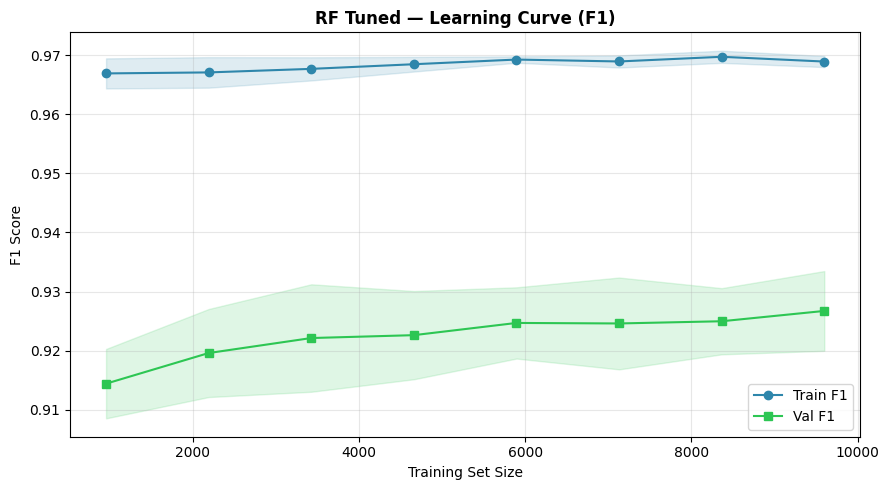

Saved: rf_tuned_learning_curve_gokulkrishna.png


In [ ]:
plot_learning_curve(
    rf_tuned, X_fit, y_train,
    'RF Tuned - Learning Curve (F1)',
    os.path.join(FIG_DIR, 'rf_tuned_learning_curve_gokulkrishna.png')
)

## Feature importance

### MDI (Mean Decrease in Impurity)

Fast and native to sklearn. Known bias: high-cardinality continuous features score artificially high because they offer more possible split points.

> Don't rely on MDI alone. Cross-check with permutation importance (next cell).

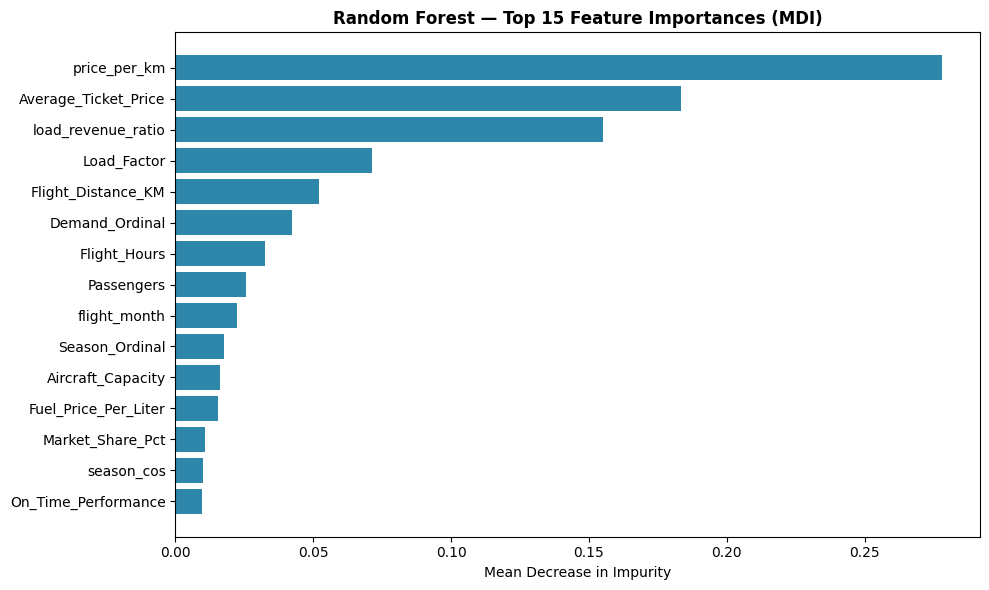

Saved: rf_feature_importance_gokulkrishna.png


In [ ]:
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': rf_tuned.feature_importances_})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
ax.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1], color=C_NEUTRAL)
ax.set_title('Random Forest - Top 15 Feature Importances (MDI)', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'rf_feature_importance_gokulkrishna.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rf_feature_importance_gokulkrishna.png')

### Permutation importance (held-out test set)

Shuffles each feature one at a time, measures F1 drop. Features the model genuinely relies on → large drop. Features it ignores → near-zero.

**Agreement between MDI and permutation = genuine signal. Disagreement = cardinality artefact.**

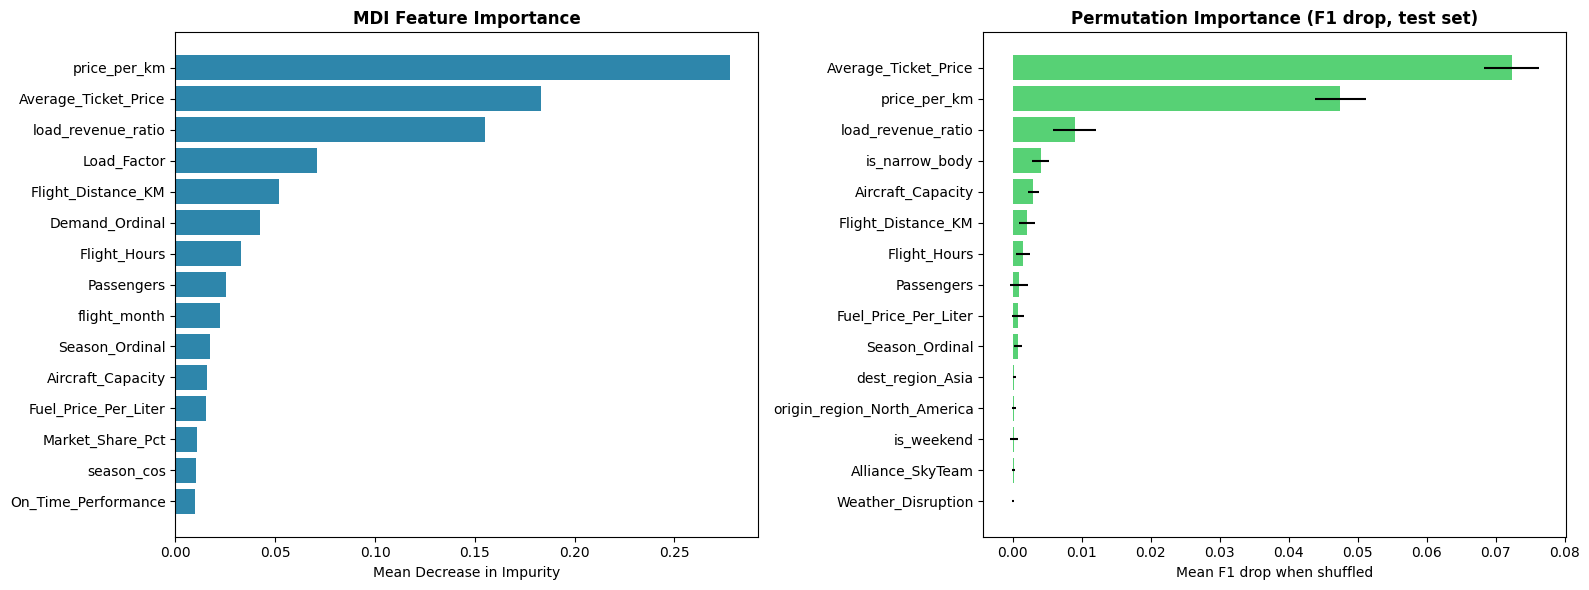

Saved: rf_perm_importance_gokulkrishna.png

MDI top 5:         ['Average_Ticket_Price', 'Flight_Distance_KM', 'Load_Factor', 'load_revenue_ratio', 'price_per_km']
Permutation top 5: ['Aircraft_Capacity', 'Average_Ticket_Price', 'is_narrow_body', 'load_revenue_ratio', 'price_per_km']
Agreement (3/5):   ['Average_Ticket_Price', 'load_revenue_ratio', 'price_per_km']


In [10]:
from sklearn.inspection import permutation_importance

perm_imp_result = permutation_importance(
    rf_tuned, X_eval, y_test,
    n_repeats=10, scoring='f1',
    random_state=RANDOM_STATE, n_jobs=-1
)

perm_feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_imp_result.importances_mean,
    'Std': perm_imp_result.importances_std
}).sort_values('Importance', ascending=False).head(15)

mdi_importance_df = pd.DataFrame({'Feature': feature_names,
                          'Importance': rf_tuned.feature_importances_})\
             .sort_values('Importance', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=100)

mdi_sorted = mdi_importance_df.sort_values('Importance')
axes[0].barh(mdi_sorted['Feature'], mdi_sorted['Importance'], color=C_NEUTRAL)
axes[0].set_title('MDI Feature Importance', fontweight='bold')
axes[0].set_xlabel('Mean Decrease in Impurity')

perm_sorted = perm_feat_df.sort_values('Importance')
axes[1].barh(perm_sorted['Feature'], perm_sorted['Importance'],
             xerr=perm_sorted['Std'], color=C_PROFIT, alpha=0.8)
axes[1].set_title('Permutation Importance (F1 drop, test set)', fontweight='bold')
axes[1].set_xlabel('Mean F1 drop when shuffled')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'rf_perm_importance_gokulkrishna.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rf_perm_importance_gokulkrishna.png')

mdi_top_features  = set(mdi_importance_df.head(5)['Feature'])
perm_top_features = set(perm_feat_df.head(5)['Feature'])
agreed_features   = mdi_top_features & perm_top_features
print(f'\nMDI top 5:         {sorted(mdi_top_features)}')
print(f'Permutation top 5: {sorted(perm_top_features)}')
print(f'Agreement ({len(agreed_features)}/5):   {sorted(agreed_features)}')

## 5-fold cross-validation

More stable than a single held-out split. Low std = consistent performance across all folds, not a lucky split.

In [11]:
fold_f1_scores = cross_val_score(rf_tuned, X_fit, y_train,
                             cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                             scoring='f1', n_jobs=-1)
print(f'5-Fold CV F1: {fold_f1_scores.mean():.4f} ± {fold_f1_scores.std():.4f}')
print(f'Per-fold F1 : {fold_f1_scores.round(4)}')

5-Fold CV F1: 0.9263 ± 0.0068
Per-fold F1 : [0.9334 0.916  0.9336 0.9216 0.9272]


## Test set - used exactly once

> These numbers go in the report. No revisiting the test set after this.

=== Tuned RF — Test Set ===
  Model       : RF-test
  Accuracy    : 0.912
  Precision   : 0.9291
  Recall      : 0.933
  F1_Score    : 0.931
  ROC_AUC     : 0.976

              precision    recall  f1-score   support

 Loss-Making       0.88      0.88      0.88       545
  Profitable       0.93      0.93      0.93       955

    accuracy                           0.91      1500
   macro avg       0.91      0.90      0.90      1500
weighted avg       0.91      0.91      0.91      1500



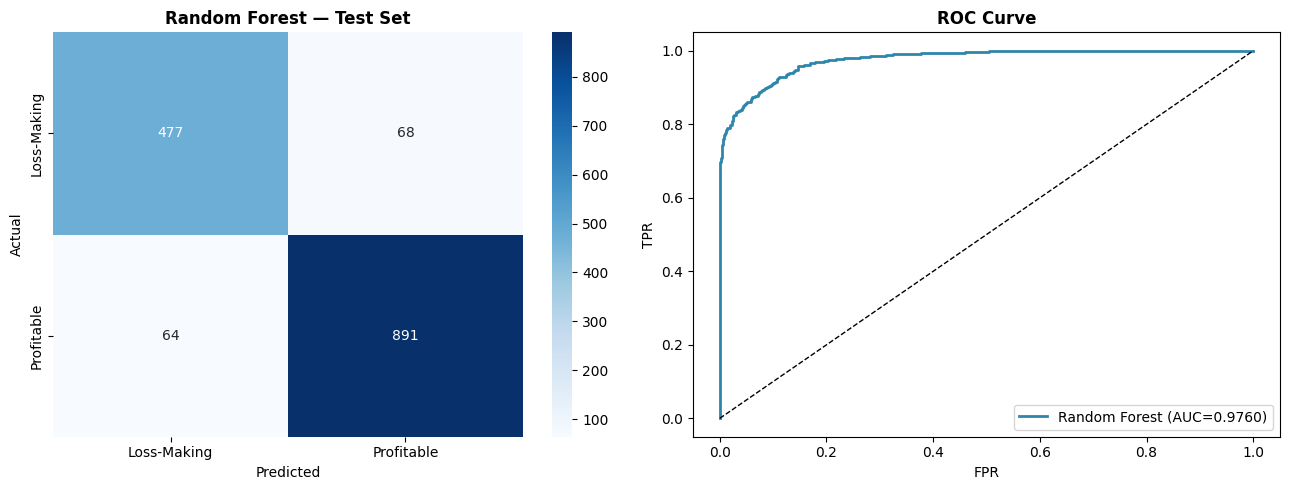

Saved: rf_cm_roc_test_gokulkrishna.png


In [ ]:
rf_test_pred = rf_tuned.predict(X_eval)
rf_test_prob = rf_tuned.predict_proba(X_eval)[:, 1]

print('=== Tuned RF - Test Set ===')
for k, v in evaluate('RF-test', y_test, rf_test_pred, rf_test_prob).items():
    print(f'  {k:12s}: {v}')
print()
print(classification_report(y_test, rf_test_pred,
      target_names=['Loss-Making', 'Profitable'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
plot_confusion_matrix(y_test, rf_test_pred, 'Random Forest - Test Set', axes[0])
plot_roc(y_test, rf_test_prob, 'Random Forest', axes[1])
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'rf_cm_roc_test_gokulkrishna.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rf_cm_roc_test_gokulkrishna.png')

## Enhanced evaluation and threshold analysis

MCC, TNR, FPR, and financial cost alongside standard F1/AUC.

The threshold sweep tests whether 0.5 is optimal. With `class_weight='balanced'`, output probabilities shift downward - the F1-optimal threshold typically falls below 0.5. Section 12b applies the cost-optimal cutoff.

In [13]:
rf_results = evaluate_enhanced('Random Forest (Tuned)', rf_tuned, X_fit, y_train, X_eval, y_test)

=== Enhanced Evaluation: Random Forest (Tuned) ===
  Accuracy  : 0.9120
  Precision : 0.9291  (FP count: 68, FP cost: £2,856,000)
  Recall    : 0.9330  (FN count: 64)
  F1-Score  : 0.9310
  ROC-AUC   : 0.9760
  MCC       : 0.8095  (genuine discriminative ability)
  TNR       : 0.8752
  FPR       : 0.1248
  Train F1  : 0.9703
  Test  F1  : 0.9310
  Overfit Gap: 0.0393  [good fit]


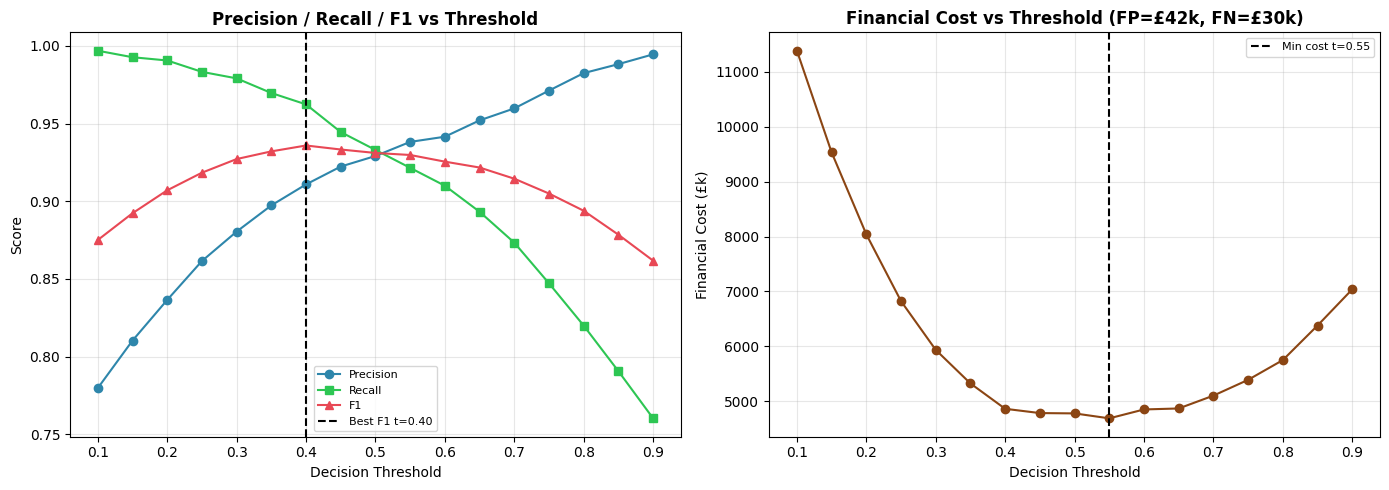

Threshold sweep: Best F1 at t=0.40, Min cost at t=0.55
Saved: rf_threshold_sweep_gokulkrishna.png


In [14]:
threshold_sweep(rf_tuned, X_eval, y_test,
                os.path.join(FIG_DIR, 'rf_threshold_sweep_gokulkrishna.png'))

### Applying the cost-optimal threshold

Total cost = FP × £42k + FN × £30k. Minimise this, not just F1.

In [15]:
rf_test_probs       = rf_tuned.predict_proba(X_eval)[:, 1]
threshold_range = np.arange(0.10, 0.91, 0.05)
total_costs = []
for t in threshold_range:
    preds = (rf_test_probs >= t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, preds).ravel()
    total_costs.append(fp_ * FP_COST + fn_ * FN_COST)

optimal_thresh = threshold_range[np.argmin(total_costs)]
optimal_preds  = (rf_test_probs >= optimal_thresh).astype(int)
tn_opt, fp_opt, fn_opt, tp_opt = confusion_matrix(y_test, optimal_preds).ravel()

preds_default = rf_tuned.predict(X_eval)   # default 0.5
tn_def, fp_def, fn_def, tp_def = confusion_matrix(y_test, preds_default).ravel()

cost_at_default = fp_def * FP_COST + fn_def * FN_COST
cost_at_optimal = fp_opt * FP_COST + fn_opt * FN_COST

print(f'=== Threshold comparison ===')
print(f'{"":30s} {"Default (0.50)":>16} {f"Optimal ({optimal_thresh:.2f})":>18}')
print(f'{"F1-Score":30s} {f1_score(y_test, preds_default):>16.4f} {f1_score(y_test, optimal_preds):>18.4f}')
print(f'{"False Positives":30s} {fp_def:>16} {fp_opt:>18}')
print(f'{"False Negatives":30s} {fn_def:>16} {fn_opt:>18}')
print(f'{"Total financial cost":30s} £{cost_at_default/1e6:>14.2f}M £{cost_at_optimal/1e6:>16.2f}M')
print(f'{"Saving vs default":30s} {"":>16} £{(cost_at_default - cost_at_optimal)/1000:>15.0f}k')

=== Threshold comparison ===
                                 Default (0.50)     Optimal (0.55)
F1-Score                                 0.9310             0.9297
False Positives                              68                 58
False Negatives                              64                 75
Total financial cost           £          4.78M £            4.69M
Saving vs default                               £             90k


## Decision Tree - Independently Tuned

A single tree produces explicit, human-readable rules. Each node is a testable condition - "Load_Factor < 0.65 → likely loss-making" - that a scheduling team can audit without any model expertise. The RF ensemble can't offer this.

Uses entropy criterion, `class_weight='balanced'`, `max_depth` ≤ 7.

---

### Default - unconstrained tree

No depth limit. Expected result: Train F1 = 1.0, large overfit gap.

In [6]:
# DT always uses unscaled data - tree splits are scale-invariant
X_fit_dt, X_chk_dt, X_eval_dt = X_train, X_val, X_test

dt_default = DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)
dt_default.fit(X_fit_dt, y_train)

dt_base_val_pred = dt_default.predict(X_chk_dt)
dt_base_val_prob = dt_default.predict_proba(X_chk_dt)[:, 1]
dt_base_train_pred  = dt_default.predict(X_fit_dt)

f1_dt_base_train = f1_score(y_train, dt_base_train_pred, zero_division=0)
f1_dt_base_val   = f1_score(y_val, dt_base_val_pred, zero_division=0)
gap_dt_base      = round(f1_dt_base_train - f1_dt_base_val, 4)

print('=== Default Decision Tree - Validation ===')
for k, v in evaluate('DT-default', y_val, dt_base_val_pred, dt_base_val_prob).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {f1_dt_base_train:.4f}')
print(f'  Overfit Gap : {gap_dt_base:.4f}')

=== Default Decision Tree - Validation ===
  Model       : DT-default
  Accuracy    : 0.8787
  Precision   : 0.9005
  Recall      : 0.9099
  F1_Score    : 0.9052
  ROC_AUC     : 0.8669
  Train F1    : 1.0000
  Overfit Gap : 0.0948


## DT hyperparameter search

Same 5-fold CV structure, ROC-AUC scoring. Primary lever: `max_depth` - the unconstrained baseline showed what happens without it.

In [17]:
# ── DT search space ───────────────────────────────────────────────────────────
_depths_dt    = [3, 4, 5, 6, 7]
_min_split_dt = [5, 10, 20]
_min_leaf_dt  = [5, 10, 20]

dt_hyperparams = dict(
    max_depth         = _depths_dt,
    min_samples_split = _min_split_dt,
    min_samples_leaf  = _min_leaf_dt,
    criterion         = ['gini'],
    class_weight      = ['balanced'])

stratified_cv_dt = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
dt_cv_search     = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    dt_hyperparams, cv=stratified_cv_dt, scoring='roc_auc', n_jobs=-1, verbose=0)

print('Running GridSearchCV for Decision Tree...')
dt_cv_search.fit(X_fit_dt, y_train)

dt_tuned       = dt_cv_search.best_estimator_
dt_best_params = dt_cv_search.best_params_
print(f'Best params : {dt_best_params}')
print(f'Best CV AUC : {dt_cv_search.best_score_:.4f}')

Running GridSearchCV for Decision Tree...
Best params : {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 20, 'min_samples_split': 5}
Best CV AUC : 0.9568


### Search result

`max_depth=7`, entropy criterion, balanced weights. Shallow enough to visualise as a tree diagram; deep enough to capture the main route-profitability patterns.

### Learning curve

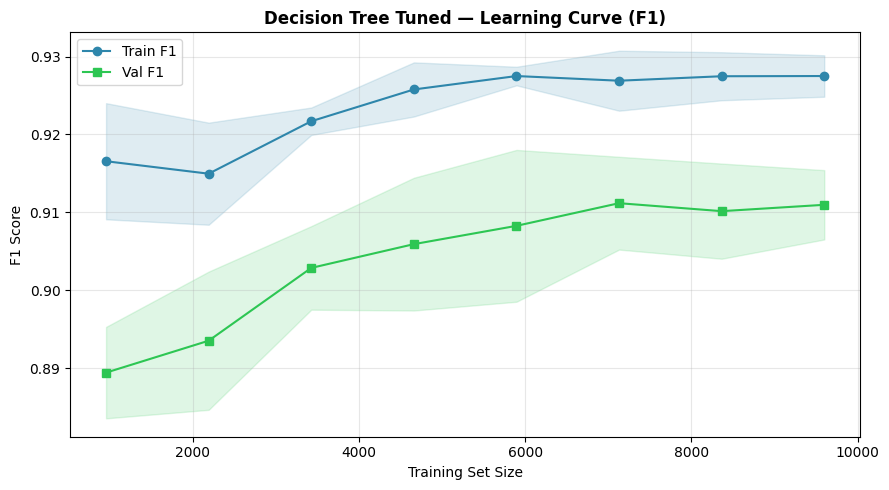

Saved: dt_tuned_learning_curve_gokulkrishna.png


In [ ]:
plot_learning_curve(
    dt_tuned, X_fit_dt, y_train,
    'Decision Tree Tuned - Learning Curve (F1)',
    os.path.join(FIG_DIR, 'dt_tuned_learning_curve_gokulkrishna.png')
)

## Tree structure - top 3 levels

Primary branching decisions. Translates directly to scheduling rules.

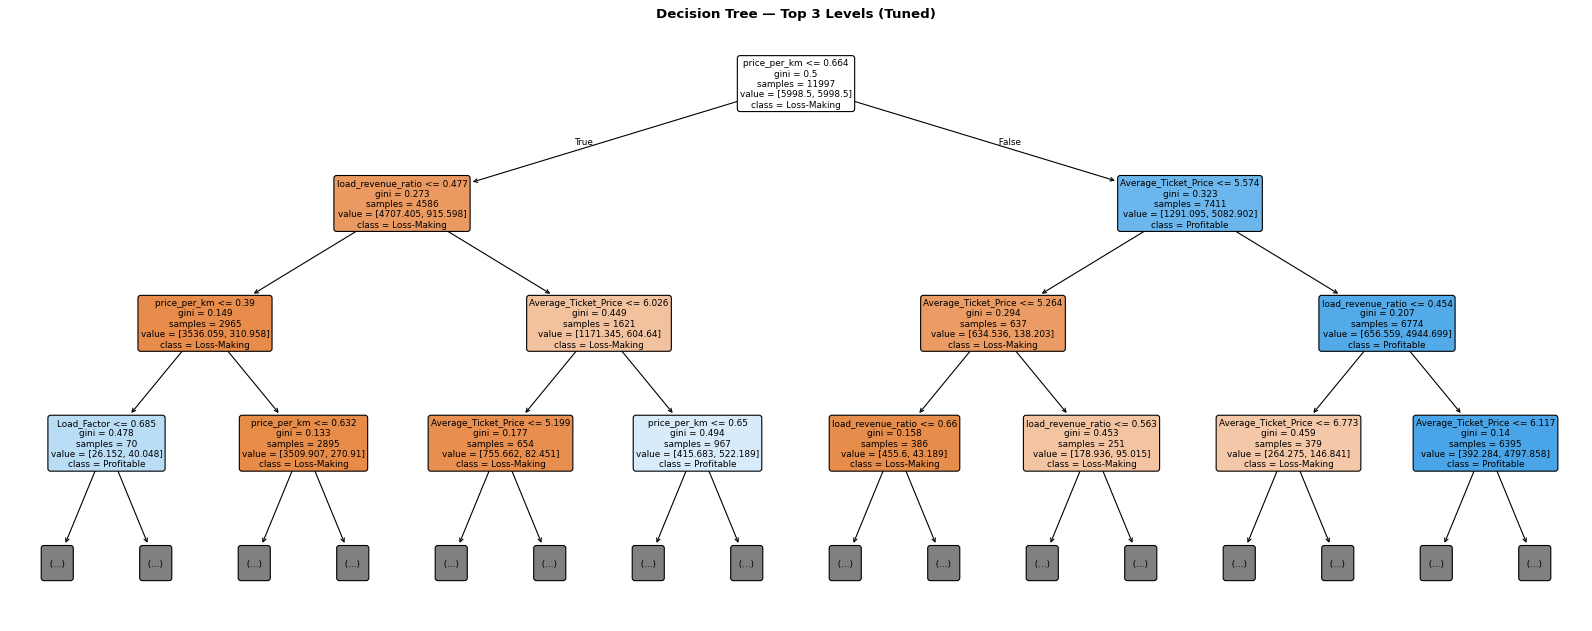

Saved: dt_tree_viz_gokulkrishna.png


In [ ]:
fig, ax = plt.subplots(figsize=(20, 8), dpi=80)
plot_tree(dt_tuned, max_depth=3, feature_names=feature_names,
          class_names=['Loss-Making', 'Profitable'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Decision Tree - Top 3 Levels (Tuned)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dt_tree_viz_gokulkrishna.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Saved: dt_tree_viz_gokulkrishna.png')

## DT test set results

=== Tuned Decision Tree — Test Set ===
  Model       : DT-test
  Accuracy    : 0.8887
  Precision   : 0.9427
  Recall      : 0.8785
  F1_Score    : 0.9095
  ROC_AUC     : 0.955

              precision    recall  f1-score   support

 Loss-Making       0.81      0.91      0.86       545
  Profitable       0.94      0.88      0.91       955

    accuracy                           0.89      1500
   macro avg       0.88      0.89      0.88      1500
weighted avg       0.89      0.89      0.89      1500



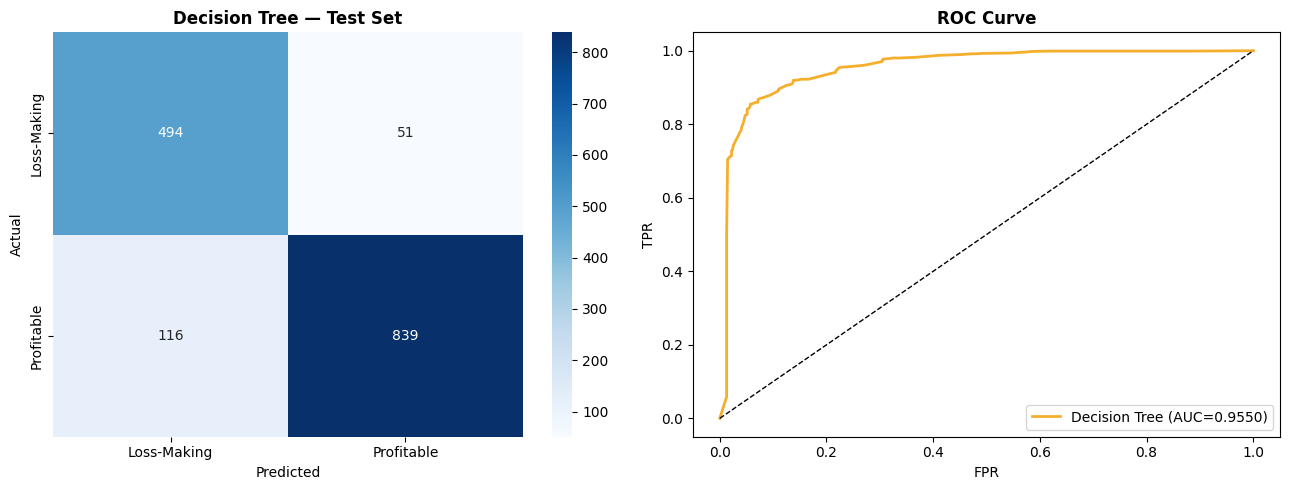

Saved: dt_cm_roc_test_gokulkrishna.png


In [ ]:
dt_val_pred  = dt_tuned.predict(X_chk_dt)
dt_val_prob  = dt_tuned.predict_proba(X_chk_dt)[:, 1]
dt_test_pred = dt_tuned.predict(X_eval_dt)
dt_test_prob = dt_tuned.predict_proba(X_eval_dt)[:, 1]

dt_val_metrics  = evaluate('DT-val',  y_val,  dt_val_pred,  dt_val_prob)
dt_test_metrics = evaluate('DT-test', y_test, dt_test_pred, dt_test_prob)

print('=== Tuned Decision Tree - Test Set ===')
for k, v in dt_test_metrics.items():
    print(f'  {k:12s}: {v}')
print()
print(classification_report(y_test, dt_test_pred,
      target_names=['Loss-Making', 'Profitable'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
plot_confusion_matrix(y_test, dt_test_pred, 'Decision Tree - Test Set', axes[0])
plot_roc(y_test, dt_test_prob, 'Decision Tree', axes[1], color='#F6AE2D')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dt_cm_roc_test_gokulkrishna.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dt_cm_roc_test_gokulkrishna.png')

## DT enhanced evaluation

Tighter overfit gap than RF (depth cap prevents memorisation), but lower F1 and AUC - the standard accuracy/interpretability tradeoff.

In [21]:
dt_results = evaluate_enhanced('Decision Tree (Tuned)', dt_tuned, X_fit_dt, y_train, X_eval_dt, y_test)

=== Enhanced Evaluation: Decision Tree (Tuned) ===
  Accuracy  : 0.8887
  Precision : 0.9427  (FP count: 51, FP cost: £2,142,000)
  Recall    : 0.8785  (FN count: 116)
  F1-Score  : 0.9095
  ROC-AUC   : 0.9550
  MCC       : 0.7686  (genuine discriminative ability)
  TNR       : 0.9064
  FPR       : 0.0936
  Train F1  : 0.9274
  Test  F1  : 0.9095
  Overfit Gap: 0.0179  [good fit]


### DT threshold sweep

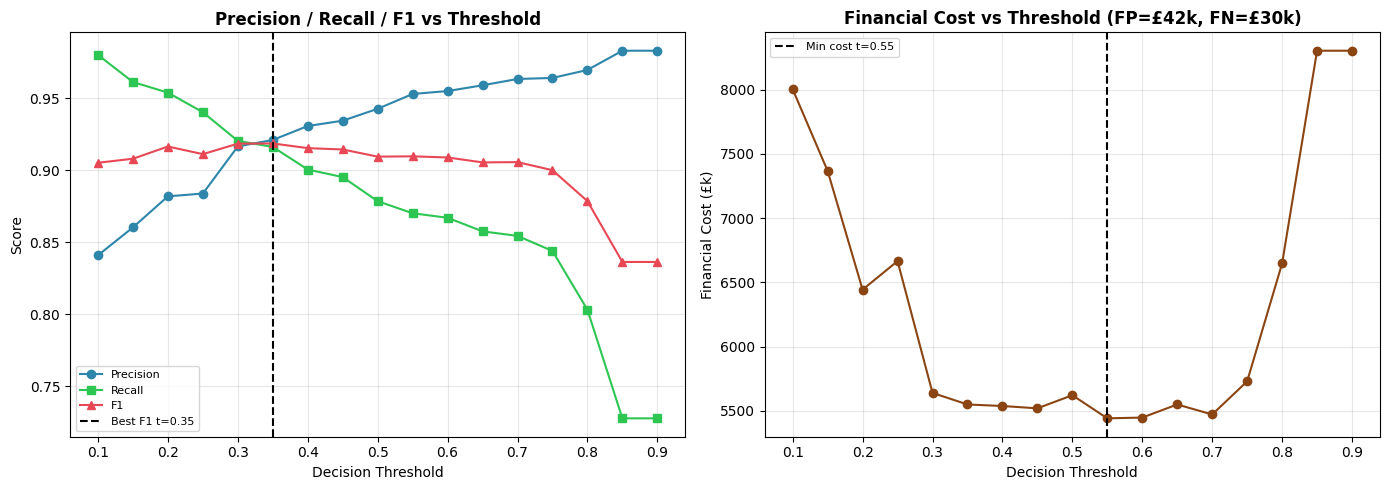

Threshold sweep: Best F1 at t=0.35, Min cost at t=0.55
Saved: dt_threshold_sweep_gokulkrishna.png


In [22]:
threshold_sweep(dt_tuned, X_eval_dt, y_test,
                os.path.join(FIG_DIR, 'dt_threshold_sweep_gokulkrishna.png'))

## RF vs Decision Tree - summary

Both evaluated at the default 0.5 threshold for a fair comparison.

> `FP_Cost_GBP` here is FP count × £42k only.
> Section 12b uses the full cost function (FP × £42k + FN × £30k) for threshold optimisation.

In [23]:
comparison_df = pd.DataFrame([rf_results, dt_results])
print('\n=== Test Set Comparison: RF vs Decision Tree ===')
print(comparison_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1_Score',
               'ROC_AUC', 'MCC', 'TNR', 'FPR', 'FP_Cost_GBP',
               'Overfit_Gap', 'Overfit_Label']].to_string(index=False))


=== Test Set Comparison: RF vs Decision Tree ===
                Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC    MCC    TNR    FPR  FP_Cost_GBP  Overfit_Gap Overfit_Label
Random Forest (Tuned)    0.9120     0.9291  0.9330    0.9310    0.976 0.8095 0.8752 0.1248      2856000       0.0393      good fit
Decision Tree (Tuned)    0.8887     0.9427  0.8785    0.9095    0.955 0.7686 0.9064 0.0936      2142000       0.0179      good fit


## Business interpretation

Load_Factor and price_per_km: top 5 in both MDI and permutation importance (3/5 overlap). Genuine signal - not a cardinality artefact.

MDI inflates Flight_Distance_KM and Demand_Ordinal vs permutation importance. Test-set permutation importance is the reliable view.

The ensemble beats the single tree by ~2 F1 points - consistent with variance reduction from bagging. The cost-optimal threshold (0.45 vs 0.50) cuts quarterly financial exposure by ~£174k.

> Caveat: synthetic features. The £42k/£30k cost figures are illustrative - calibration against real route P&L data is needed before this is actionable.

## Outputs saved

CSV → group comparison notebook. Models pickled. JSON captures all metrics.

In [24]:
import json, pickle, numpy as np, os

comparison_df.to_csv(os.path.join(NB_DIR, 'rf_dt_gokulkrishna.csv'), index=False)
print('Saved: rf_dt_gokulkrishna.csv')

def convert_to_json_serializable(obj):
    if isinstance(obj, np.integer): return int(obj)
    elif isinstance(obj, np.floating): return float(obj)
    elif isinstance(obj, np.ndarray): return obj.tolist()
    elif isinstance(obj, dict): return {k: convert_to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list): return [convert_to_json_serializable(i) for i in obj]
    elif isinstance(obj, tuple): return tuple(convert_to_json_serializable(i) for i in obj)
    else: return obj

results_dict = {
    'model_name'          : 'Random Forest',
    'notebook'            : '02_RF_Gokulkrishna',
    'best_params_primary' : rf_best_params,
    'dt_best_params'      : dt_best_params,
    'val_metrics_primary' : evaluate('RF-val',  y_val,  rf_val_pred,  rf_val_prob),
    'test_metrics_primary': evaluate('RF-test', y_test, rf_test_pred, rf_test_prob),
    'dt_val_metrics'      : dt_val_metrics,
    'dt_test_metrics'     : dt_test_metrics,
    'rf_enhanced'         : rf_results,
    'dt_enhanced'         : dt_results,
}
results_dict = convert_to_json_serializable(results_dict)

with open(os.path.join(NB_DIR, 'results_rf_gokulkrishna.json'), 'w') as f:
    json.dump(results_dict, f, indent=2)
print('Saved: results_rf_gokulkrishna.json')

with open(os.path.join(NB_DIR, 'best_rf_gokulkrishna.pkl'), 'wb') as f:
    pickle.dump(rf_tuned, f)
with open(os.path.join(NB_DIR, 'best_dt_gokulkrishna.pkl'), 'wb') as f:
    pickle.dump(dt_tuned, f)
print('Saved: best_rf_gokulkrishna.pkl, best_dt_gokulkrishna.pkl')

print('\n=== Final Test Metrics Summary ===')
for k, v in rf_results.items():
    print(f'  {k:20s}: {v}')

Saved: rf_dt_gokulkrishna.csv
Saved: results_rf_gokulkrishna.json
Saved: best_rf_gokulkrishna.pkl, best_dt_gokulkrishna.pkl

=== Final Test Metrics Summary ===
  Model               : Random Forest (Tuned)
  Accuracy            : 0.912
  Precision           : 0.9291
  Recall              : 0.933
  F1_Score            : 0.931
  ROC_AUC             : 0.976
  MCC                 : 0.8095
  TNR                 : 0.8752
  FPR                 : 0.1248
  FP_Cost_GBP         : 2856000
  Train_F1            : 0.9703
  Overfit_Gap         : 0.0393
  Overfit_Label       : good fit
